In [1]:
import pandas as pd

labels_df = pd.read_csv('C:/Users/samya/PyCharmProject/Pneumonia-Detection_dataset/data/stage_2_train_labels.csv')
labels_df = labels_df[labels_df['Target'] == 1]  # Only pneumonia cases


In [27]:
def create_segmentation_mask(img_id, boxes_df, orig_size=(1024, 1024), new_size=(64, 64)):
    """
    Create a binary mask from bounding boxes for one image.
    """
    mask = np.zeros(new_size, dtype=np.uint8)

    boxes = boxes_df[boxes_df['patientId'] == img_id]
    for _, row in boxes.iterrows():
        # Scale coordinates
        x1 = int(row['x'] / orig_size[0] * new_size[0])
        y1 = int(row['y'] / orig_size[1] * new_size[1])
        x2 = int((row['x'] + row['width']) / orig_size[0] * new_size[0])
        y2 = int((row['y'] + row['height']) / orig_size[1] * new_size[1])
        
        # Draw rectangle
        mask[y1:y2, x1:x2] = 1

    return mask


In [3]:
import os
import pydicom
import cv2
import numpy as np
from tqdm import tqdm

TRAIN_IMG_DIR = "C:/Users/samya/PyCharmProject/Pneumonia-Detection_dataset/data/stage_2_train_images"

image_paths = [os.path.join(TRAIN_IMG_DIR, f) for f in os.listdir(TRAIN_IMG_DIR) if f.endswith(".dcm")]

X = []
y = []

for path in tqdm(image_paths):  # Use a subset for faster development
    img_id = os.path.basename(path).replace('.dcm', '')
    ds = pydicom.dcmread(path)
    img = ds.pixel_array
    img = cv2.resize(img, (64, 64))
    img = img / 255.0
    img_rgb = np.repeat(img[..., np.newaxis], 3, axis=-1)

    mask = create_segmentation_mask(img_id, labels_df, orig_size=ds.pixel_array.shape, new_size=(64, 64))
    mask = mask[..., np.newaxis]  # shape: (64, 64, 1)

    X.append(img_rgb)
    y.append(mask)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.uint8)


100%|██████████| 26684/26684 [22:47<00:00, 19.51it/s]


In [8]:
import tensorflow as tf

# Clear, Flexible Exponential Decay Function
def exponential_decay(lr_initial, decay_steps, decay_rate=0.1):
    """
    Returns a function that computes exponentially decaying learning rate.
    
    Parameters:
    - lr_initial: Initial learning rate
    - decay_steps: Controls the rate of decay
    - decay_rate: The base of the exponential decay (default: 0.1)

    Returns:
    - A function that takes an epoch index and returns the decayed learning rate
    """
    def schedule(epoch):
        return lr_initial * decay_rate ** (epoch / decay_steps)
    return schedule

# Define the scheduler function
exponential_decay_fn = exponential_decay(lr_initial=0.01, decay_steps=20)

# Learning Rate Scheduler Callback
lr_scheduler_cb = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn, verbose=1)

# Model Checkpoint Callback (saves best model only)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="xray_model.h5",
    save_best_only=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

# Early Stopping Callback (restores best weights after patience period)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)


In [9]:
# These our our scoring metrics that are going to be used to evaluate our models
METRICS = ['accuracy', 
           tf.keras.metrics.Precision(name='precision'), 
           tf.keras.metrics.Recall(name='recall'), 
           tf.keras.metrics.AUC(name='AUC')]

In [10]:
# After creating full X and y arrays (could be 30K+)
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.uint8)

# ✅ Select first 5000 examples
X = X[:2000]
y = y[:2000]

# Then split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
from tensorflow.keras import layers, models, Input

def build_unet(input_shape=(64, 64, 3)):
    inputs = Input(input_shape)

    # --- Encoder ---
    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        return x

    def encoder_block(x, filters):
        f = conv_block(x, filters)
        p = layers.MaxPooling2D(pool_size=(2, 2))(f)
        return f, p

    def decoder_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        return conv_block(x, filters)

    # Downsampling path
    f1, p1 = encoder_block(inputs, 32)
    f2, p2 = encoder_block(p1, 64)
    f3, p3 = encoder_block(p2, 128)

    # Bottleneck
    b = conv_block(p3, 256)

    # Upsampling path
    d1 = decoder_block(b, f3, 128)
    d2 = decoder_block(d1, f2, 64)
    d3 = decoder_block(d2, f1, 32)

    # Output layer
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d3)

    model = models.Model(inputs, outputs, name='UNet')
    return model

In [35]:
model = build_unet((64, 64, 3))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()



Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 64, 64,    │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_30[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ conv2d_31[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_32[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ conv2d_33[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 16, 16,    │    147,584 │ conv2d_34[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 8, 8, 128) │          0 │ conv2d_35[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 8, 8, 256) │    590,080 │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 16, 16,    │    131,200 │ conv2d_37[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_35[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 16, 16,    │    295,040 │ concatenate_6[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 16, 16,    │    147,584 │ conv2d_38[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 32, 32,    │     32,832 │ conv2d_39[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,925,601 (7.35 MB)

 Trainable params: 1,925,601 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=256,
    epochs=20,
    callbacks=[checkpoint_cb, early_stopping_cb, lr_scheduler_cb]
)


Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6264 - loss: 1.7740
Epoch 1: val_loss did not improve from 0.20670
7/7 ━━━━━━━━━━━━━━━━━━━━ 69s 9s/step - accuracy: 0.6501 - loss: 1.7811 - val_accuracy: 0.9493 - val_loss: 3.3098 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.008912509381337455.
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9595 - loss: 1.3514
Epoch 2: val_loss did not improve from 0.20670
7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.9594 - loss: 1.2961 - val_accuracy: 0.9493 - val_loss: 0.5758 - learning_rate: 0.0089

Epoch 3: LearningRateScheduler setting learning rate to 0.007943282347242816.
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9580 - loss: 0.5584
Epoch 3: val_loss did not improve from 0.20670
7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 7s/step - accuracy: 0.9580 - loss: 0.5570 - val_accuracy: 0.9493 - val_loss: 0.5200 - learni

7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.9582 - loss: 0.1897 - val_accuracy: 0.9493 - val_loss: 0.2018 - learning_rate: 0.0040

Epoch 10: LearningRateScheduler setting learning rate to 0.003548133892335755.
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9548 - loss: 0.3182
Epoch 10: val_loss did not improve from 0.20176
7/7 ━━━━━━━━━━━━━━━━━━━━ 53s 8s/step - accuracy: 0.9552 - loss: 0.3123 - val_accuracy: 0.9493 - val_loss: 0.2086 - learning_rate: 0.0035

Epoch 11: LearningRateScheduler setting learning rate to 0.0031622776601683794.
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9597 - loss: 0.1775
Epoch 11: val_loss improved from 0.20176 to 0.19084, saving model to xray_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.9595 - loss: 0.1779 - val_accuracy: 0.9493 - val_loss: 0.1908 - learning_rate: 0.0032

Epoch 12: LearningRateScheduler setting learning rate to 0.002818382931264454.
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9588 - loss: 0.1666
Epoch 12: val_loss did not improve from 0.19084
7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.9588 - loss: 0.1668 - val_accuracy: 0.9493 - val_loss: 0.1919 - learning_rate: 0.0028

Epoch 13: LearningRateScheduler setting learning rate to 0.0025118864315095803.
Epoch 13/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9592 - loss: 0.1646
Epoch 13: val_loss improved from 0.19084 to 0.17875, saving model to xray_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.9591 - loss: 0.1647 - val_accuracy: 0.9493 - val_loss: 0.1788 - learning_rate: 0.0025

Epoch 14: LearningRateScheduler setting learning rate to 0.0022387211385683395.
Epoch 14/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9596 - loss: 0.1565
Epoch 14: val_loss did not improve from 0.17875
7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 7s/step - accuracy: 0.9594 - loss: 0.1568 - val_accuracy: 0.9493 - val_loss: 0.1813 - learning_rate: 0.0022

Epoch 15: LearningRateScheduler setting learning rate to 0.0019952623149688802.
Epoch 15/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9577 - loss: 0.1595
Epoch 15: val_loss improved from 0.17875 to 0.17749, saving model to xray_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 7s/step - accuracy: 0.9578 - loss: 0.1591 - val_accuracy: 0.9493 - val_loss: 0.1775 - learning_rate: 0.0020

Epoch 16: LearningRateScheduler setting learning rate to 0.001778279410038923.
Epoch 16/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9579 - loss: 0.1561
Epoch 16: val_loss improved from 0.17749 to 0.17608, saving model to xray_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.9579 - loss: 0.1558 - val_accuracy: 0.9493 - val_loss: 0.1761 - learning_rate: 0.0018

Epoch 17: LearningRateScheduler setting learning rate to 0.0015848931924611134.
Epoch 17/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9558 - loss: 0.1616
Epoch 17: val_loss did not improve from 0.17608
7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 7s/step - accuracy: 0.9561 - loss: 0.1606 - val_accuracy: 0.9493 - val_loss: 0.1767 - learning_rate: 0.0016

Epoch 18: LearningRateScheduler setting learning rate to 0.0014125375446227546.
Epoch 18/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9582 - loss: 0.1534
Epoch 18: val_loss improved from 0.17608 to 0.17606, saving model to xray_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 7s/step - accuracy: 0.9582 - loss: 0.1533 - val_accuracy: 0.9493 - val_loss: 0.1761 - learning_rate: 0.0014

Epoch 19: LearningRateScheduler setting learning rate to 0.0012589254117941673.
Epoch 19/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9608 - loss: 0.1467
Epoch 19: val_loss improved from 0.17606 to 0.17458, saving model to xray_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 53s 7s/step - accuracy: 0.9605 - loss: 0.1475 - val_accuracy: 0.9493 - val_loss: 0.1746 - learning_rate: 0.0013

Epoch 20: LearningRateScheduler setting learning rate to 0.0011220184543019637.
Epoch 20/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9568 - loss: 0.1573
Epoch 20: val_loss did not improve from 0.17458
7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 7s/step - accuracy: 0.9570 - loss: 0.1567 - val_accuracy: 0.9493 - val_loss: 0.1798 - learning_rate: 0.0011
Restoring model weights from the end of the best epoch: 19.


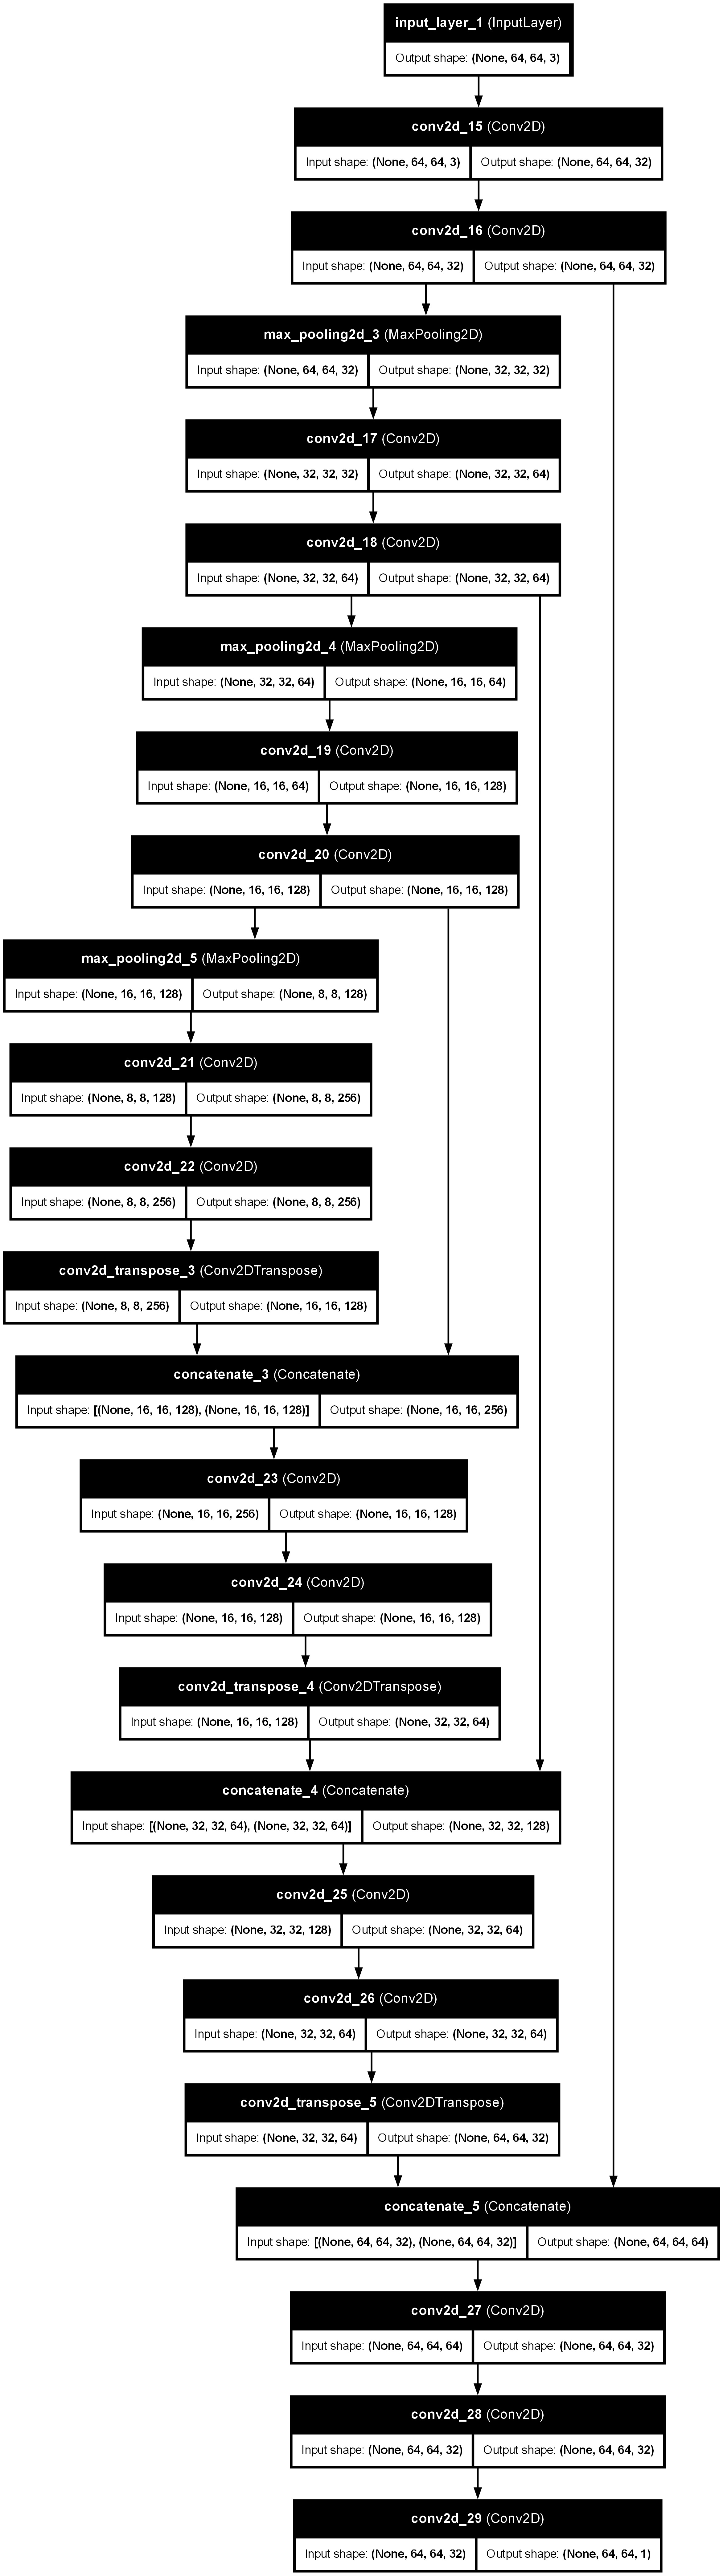

In [21]:
from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes=True, show_layer_names=True, to_file="unet_model.png")


Using DICOM file: C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images\d5e9f517-48f2-4eb4-9ef8-1fc91ec9490e.dcm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


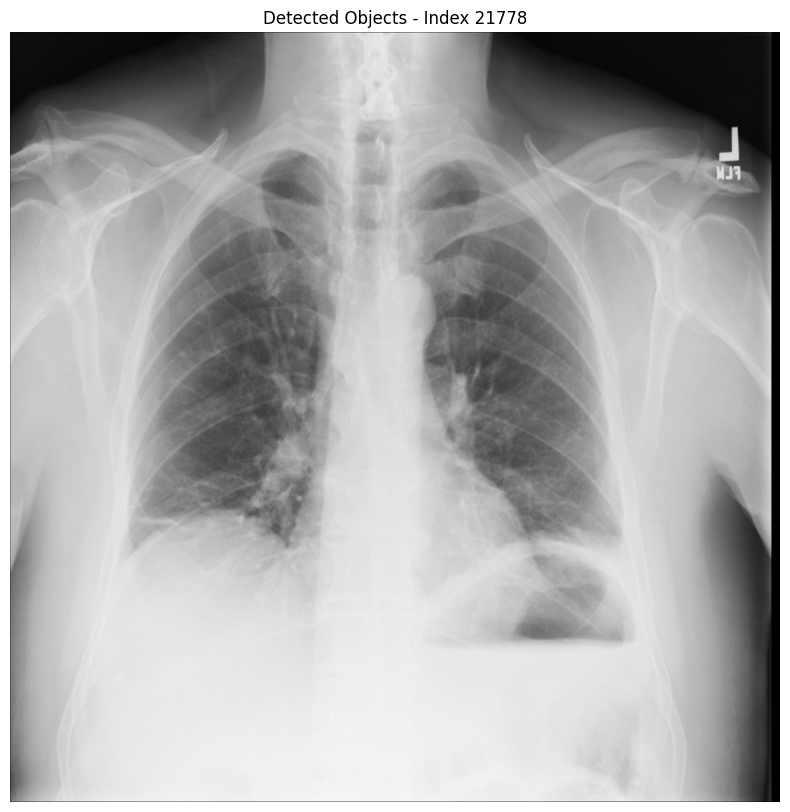

In [41]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pydicom




from tensorflow.keras.models import load_model

# --- Define DICOM path loader ---
def get_dicom_paths(directory):
    return [os.path.join(directory, fname) for fname in os.listdir(directory) if fname.endswith(".dcm")]

# --- Directories ---
TRAIN_IMG_DIR = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
train_img_path = get_dicom_paths(TRAIN_IMG_DIR)

# --- Load U-Net model ---
model = load_model(r'C:\Users\samya\PyCharmProject\Pneumonia-Detection\xray_model.h5')  # Replace with your actual model path

# --- Select a random image beyond the first 5000 ---
random_index = random.choice(range(5000, len(train_img_path)))
dicom_path = train_img_path[random_index]
print(f"Using DICOM file: {dicom_path}")

# --- Load and preprocess DICOM image ---
dicom = pydicom.dcmread(dicom_path)
image = dicom.pixel_array.astype(np.float32)
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
original_size = image.shape

# Resize to model input size and convert to 3 channels
input_image = cv2.resize(image, (64, 64))
input_image = cv2.cvtColor(input_image, cv2.COLOR_GRAY2RGB)
input_image = input_image / 255.0
input_image = np.expand_dims(input_image, axis=0)  # Shape: (1, 64, 64, 3)

# --- Predict segmentation mask ---
predicted_mask = model.predict(input_image)[0, :, :, 0]
binary_mask = (predicted_mask > 0.5).astype(np.uint8) * 255
binary_mask_resized = cv2.resize(binary_mask, (original_size[1], original_size[0]))

# --- Find contours and draw bounding boxes ---
contours, _ = cv2.findContours(binary_mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

# --- Display result ---
plt.figure(figsize=(10, 10))
plt.imshow(output_image)
plt.title(f"Detected Objects - Index {random_index}")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


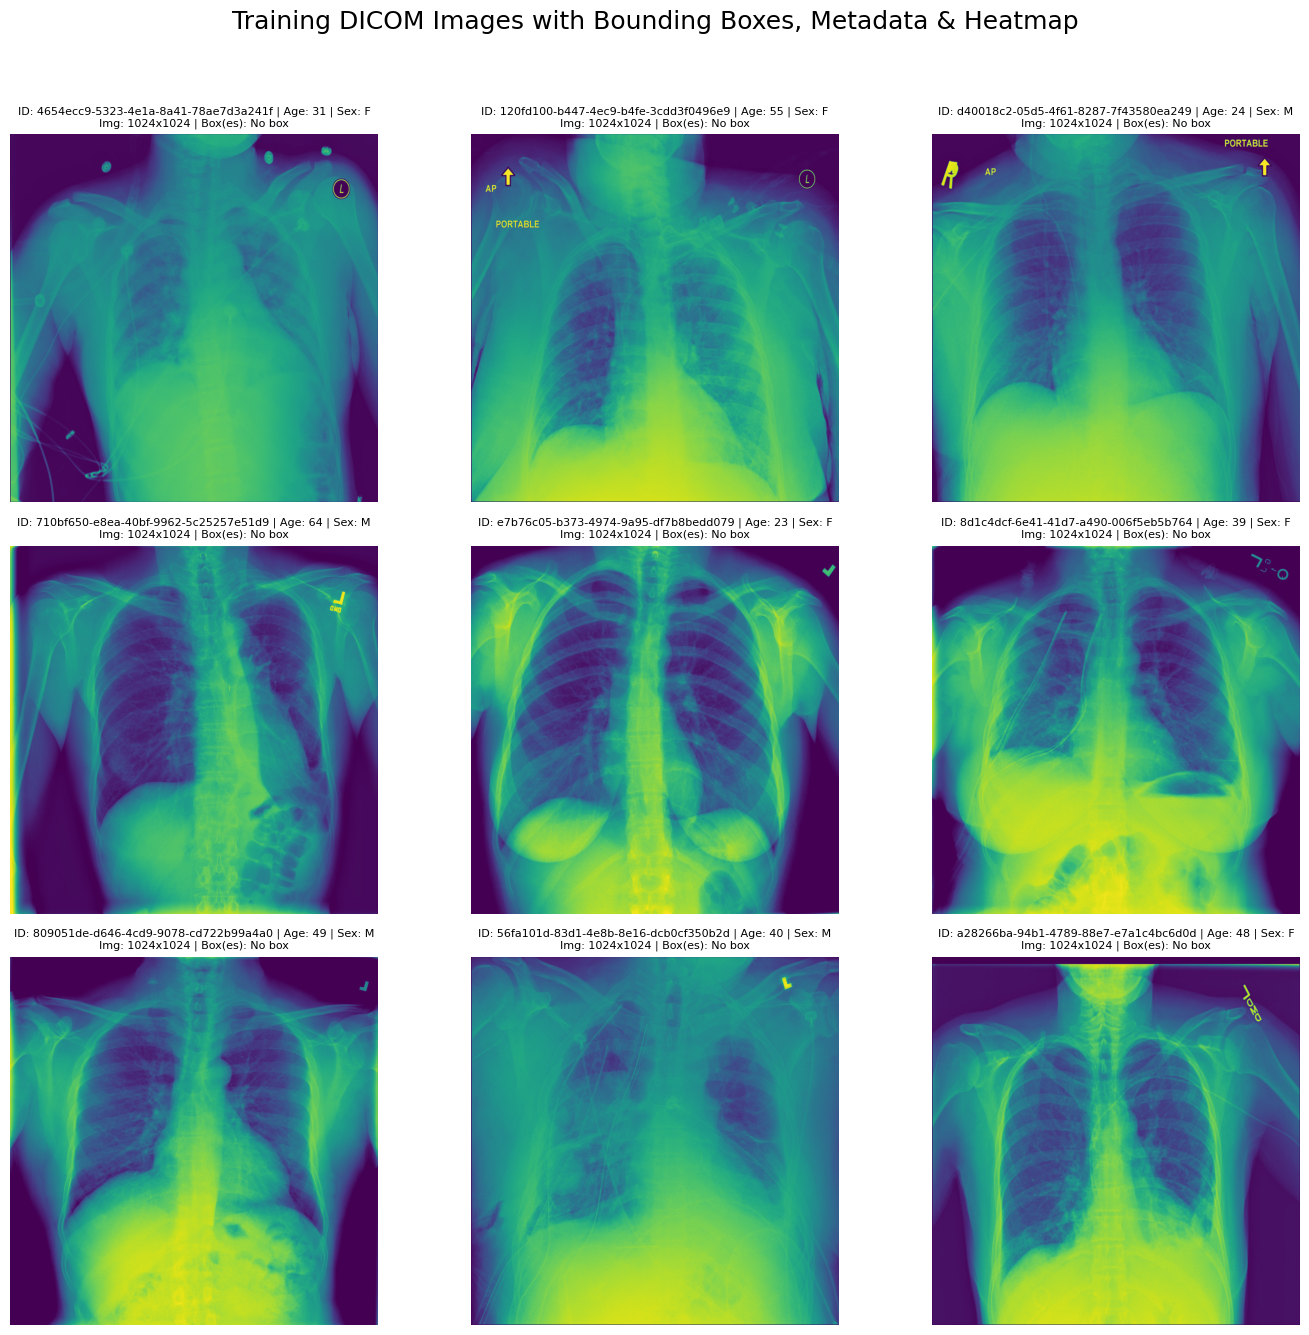

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


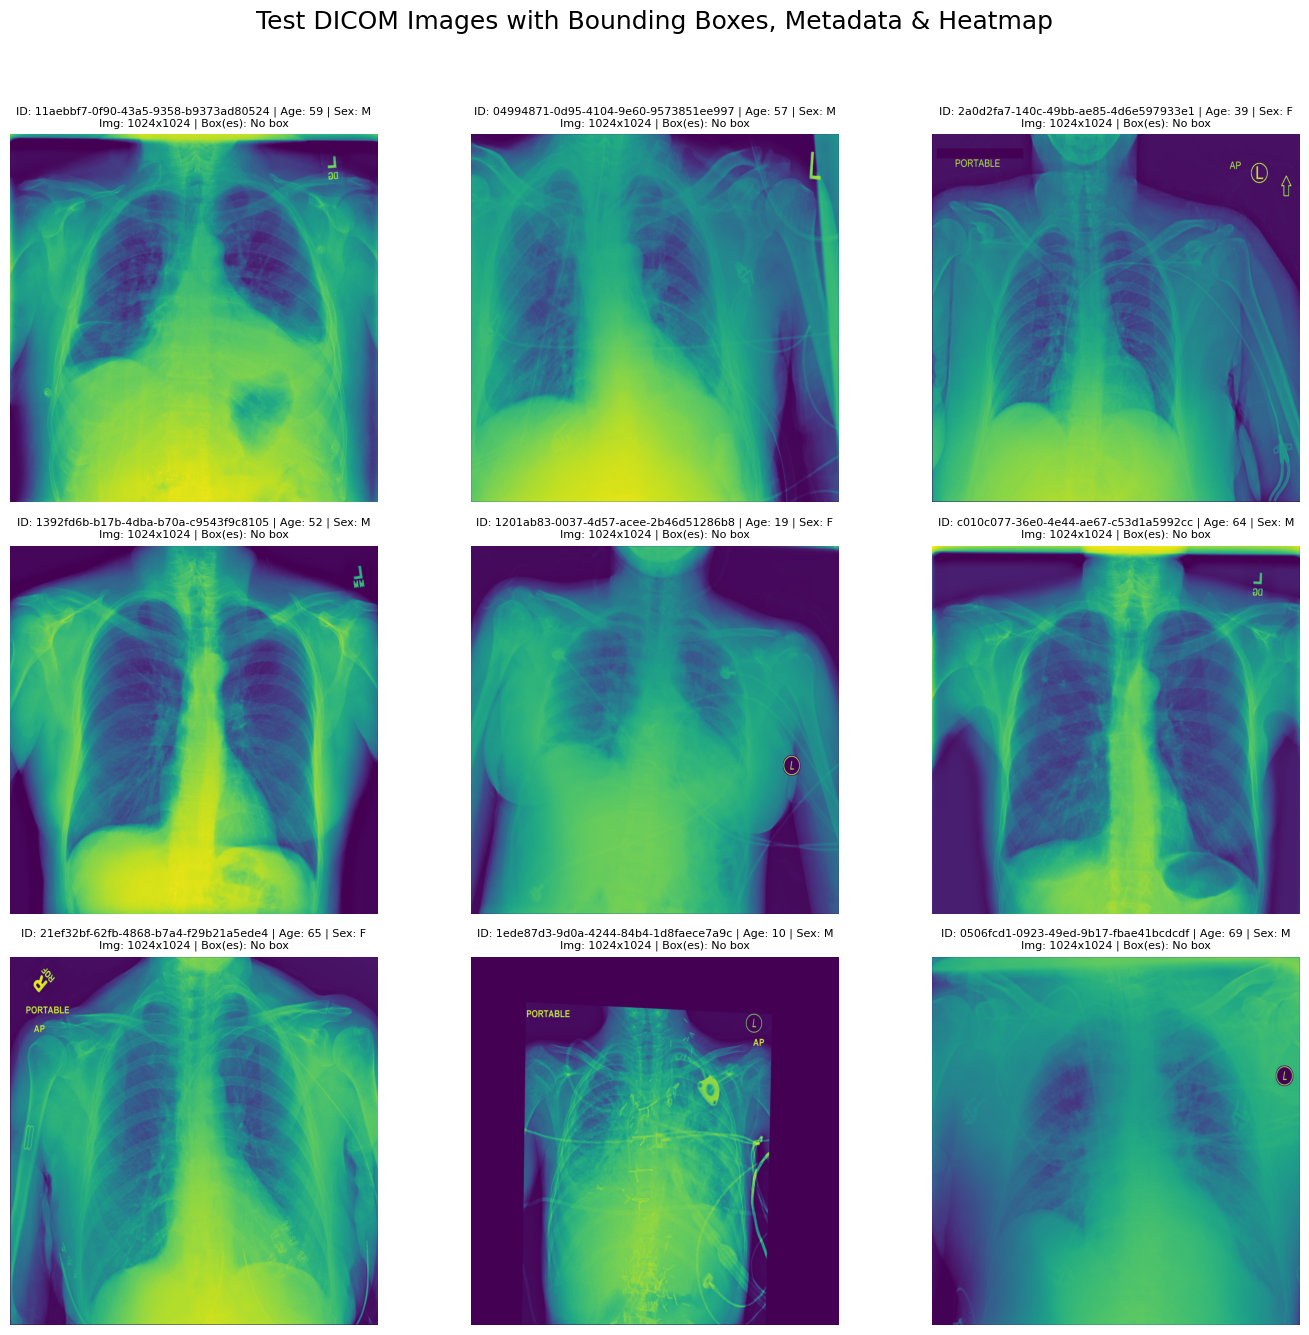

In [38]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pydicom
from tensorflow.keras.models import load_model

# --- Define DICOM path loader ---
def get_dicom_paths(directory):
    return [os.path.join(directory, fname) for fname in os.listdir(directory) if fname.endswith(".dcm")]

# --- Directories ---
TRAIN_IMG_DIR = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
TEST_IMG_DIR  = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_test_images"
MODEL_PATH    = r'C:\Users\samya\PyCharmProject\Pneumonia-Detection\xray_model.h5'

# --- Load U-Net model ---
model = load_model(MODEL_PATH)

# --- Load paths ---
train_img_paths = get_dicom_paths(TRAIN_IMG_DIR)
test_img_paths = get_dicom_paths(TEST_IMG_DIR)

# --- Function to process and visualize with heatmap, predictions, and metadata ---
def process_and_display_with_boxes(image_paths, title):
    fig, axes = plt.subplots(3, 3, figsize=(14, 14))
    fig.suptitle(title, fontsize=18)

    for ax, path in zip(axes.flatten(), image_paths):
        ds = pydicom.dcmread(path)
        image = ds.pixel_array.astype(np.float32)
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        original_size = image.shape

        # Resize and prepare for model
        input_image = cv2.resize(image, (64, 64))
        input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_GRAY2RGB)
        input_image_norm = input_image_rgb / 255.0
        input_image_norm = np.expand_dims(input_image_norm, axis=0)

        # Predict and threshold
        predicted_mask = model.predict(input_image_norm)[0, :, :, 0]
        binary_mask = (predicted_mask > 0.5).astype(np.uint8) * 255
        binary_mask_resized = cv2.resize(binary_mask, (original_size[1], original_size[0]))

        # Apply heatmap to original grayscale image
        heatmap_image = cv2.applyColorMap(image, cv2.COLORMAP_VIRIDIS)


        # Find contours and draw bounding boxes
        contours, _ = cv2.findContours(binary_mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        output_image = heatmap_image.copy()
        box_labels = []

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green box
            box_labels.append(f"{w}x{h}")

        # --- Extract metadata ---
        patient_id = getattr(ds, "PatientID", "N/A")
        patient_age = getattr(ds, "PatientAge", "N/A")
        patient_sex = getattr(ds, "PatientSex", "N/A")
        dimensions = f"{original_size[0]}x{original_size[1]}"
        box_str = "; ".join(box_labels) if box_labels else "No box"

        # --- Show image ---
        ax.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        ax.set_title(
            f"ID: {patient_id} | Age: {patient_age} | Sex: {patient_sex}\n"
            f"Img: {dimensions} | Box(es): {box_str}",
            fontsize=8
        )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave room for suptitle
    plt.show()

# --- Randomly select 9 images from train and test ---
train_samples = random.sample(train_img_paths, 9)
test_samples = random.sample(test_img_paths, 9)

# --- Plot with heatmap, predictions, boxes, and metadata ---
process_and_display_with_boxes(train_samples, "Training DICOM Images with Bounding Boxes, Metadata & Heatmap")
process_and_display_with_boxes(test_samples, "Test DICOM Images with Bounding Boxes, Metadata & Heatmap")


In [39]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pydicom
from tensorflow.keras.models import load_model

# --- Define DICOM path loader ---
def get_dicom_paths(directory):
    return [os.path.join(directory, fname) for fname in os.listdir(directory) if fname.endswith(".dcm")]

# --- Directories ---
TRAIN_IMG_DIR = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
TEST_IMG_DIR  = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_test_images"
MODEL_PATH    = r'C:\Users\samya\PyCharmProject\Pneumonia-Detection\xray_model.h5'

# --- Load U-Net model ---
model = load_model(MODEL_PATH)

# --- Load paths ---
train_img_paths = get_dicom_paths(TRAIN_IMG_DIR)
test_img_paths = get_dicom_paths(TEST_IMG_DIR)

# --- Function to process and visualize with heatmap, predictions, and metadata ---
def process_and_display_with_boxes(image_paths, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    fig.suptitle(title, fontsize=18)

    for ax, path in zip(axes.flatten(), image_paths):
        ds = pydicom.dcmread(path)
        image = ds.pixel_array.astype(np.float32)
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        original_size = image.shape

        # Resize and prepare for model
        input_image = cv2.resize(image, (64, 64))
        input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_GRAY2RGB)
        input_image_norm = input_image_rgb / 255.0
        input_image_norm = np.expand_dims(input_image_norm, axis=0)

        # Predict and threshold
        predicted_mask = model.predict(input_image_norm)[0, :, :, 0]
        binary_mask = (predicted_mask > 0.5).astype(np.uint8) * 255
        binary_mask_resized = cv2.resize(binary_mask, (original_size[1], original_size[0]))

        # Apply VIRIDIS colormap to original grayscale image
        heatmap_image = cv2.applyColorMap(image, cv2.COLORMAP_VIRIDIS)

        # Find contours and draw red bounding boxes
        contours, _ = cv2.findContours(binary_mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        output_image = heatmap_image.copy()
        box_labels = []

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 0, 255), 2)  
            box_labels.append(f"{w}x{h}")

        # --- Extract metadata ---
        patient_id = getattr(ds, "PatientID", "N/A")
        patient_age = getattr(ds, "PatientAge", "N/A")
        patient_sex = getattr(ds, "PatientSex", "N/A")
        view_pos = getattr(ds, "ViewPosition", "N/A")
        dimensions = f"{original_size[0]}x{original_size[1]}"
        box_str = "; ".join(box_labels) if box_labels else "No box"

        # --- Show image ---
        ax.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        ax.set_title(
            f"ID: {patient_id} | Age: {patient_age} | Sex: {patient_sex} | View: {view_pos}\n"
            f"Size: {dimensions} | Box(es): {box_str}",
            fontsize=8
        )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave room for suptitle
    plt.show()

# --- Randomly select 9 images from train and test ---
train_samples = random.sample(train_img_paths, 9)
test_samples = random.sample(test_img_paths, 9)




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


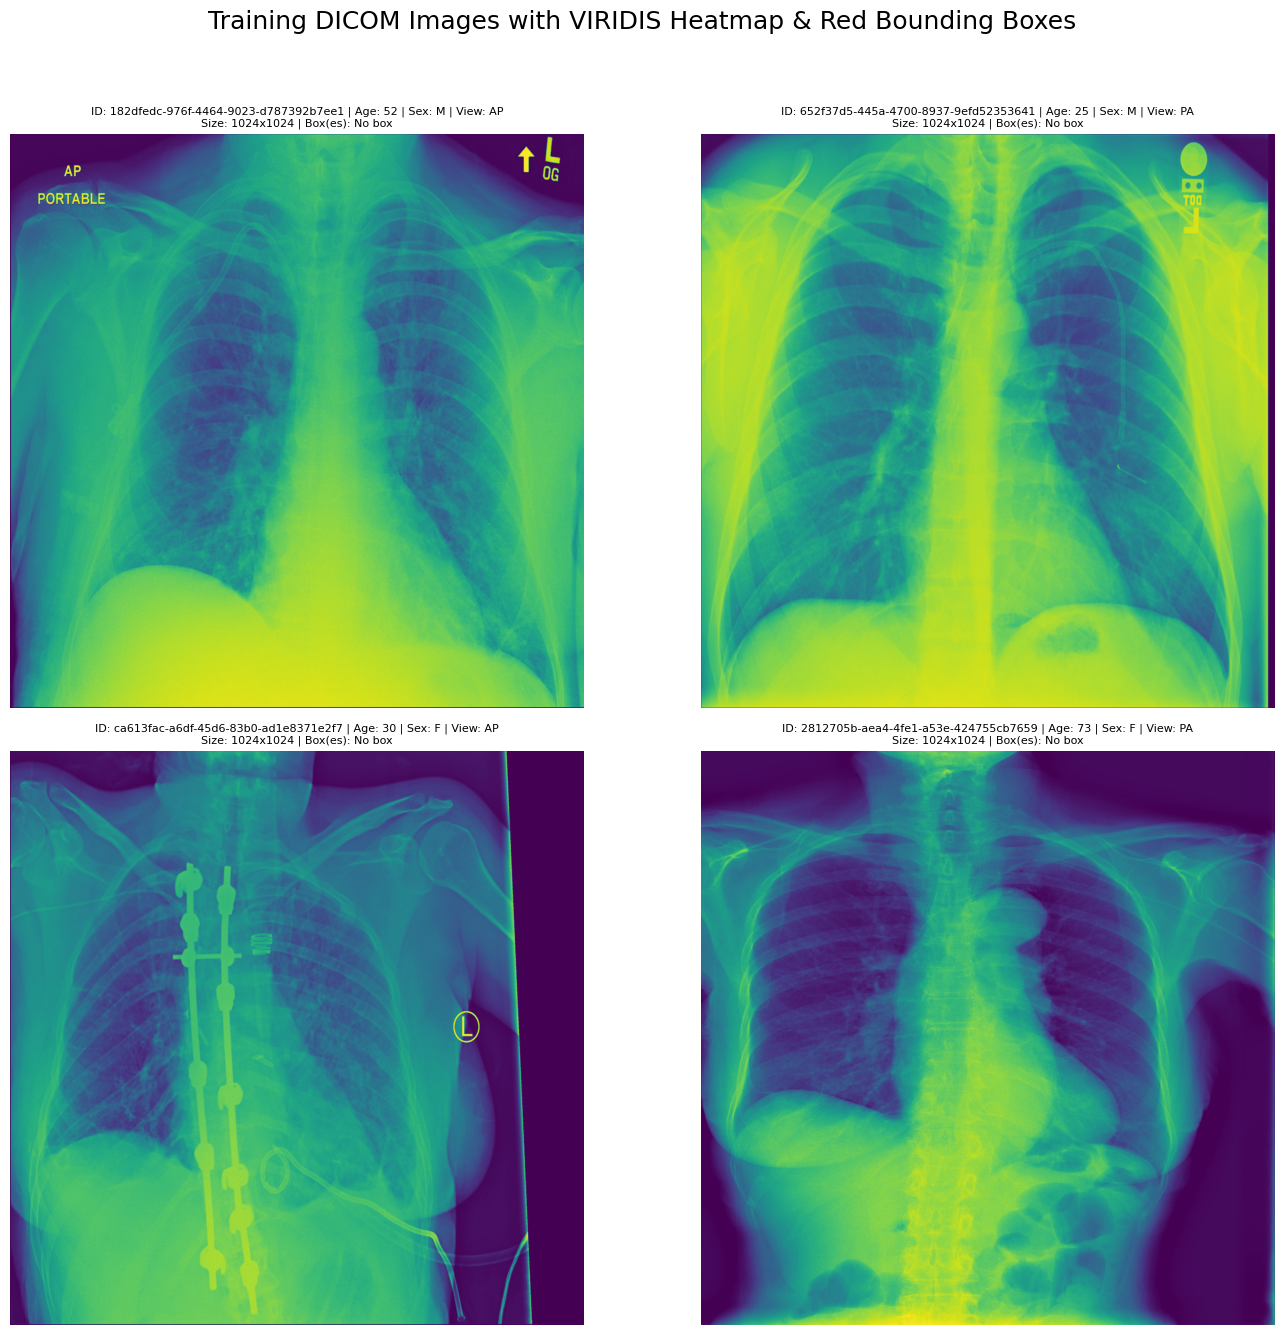

In [40]:
# --- Plot with heatmap, predictions, boxes, and metadata ---
process_and_display_with_boxes(train_samples, "Training DICOM Images with VIRIDIS Heatmap & Red Bounding Boxes")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


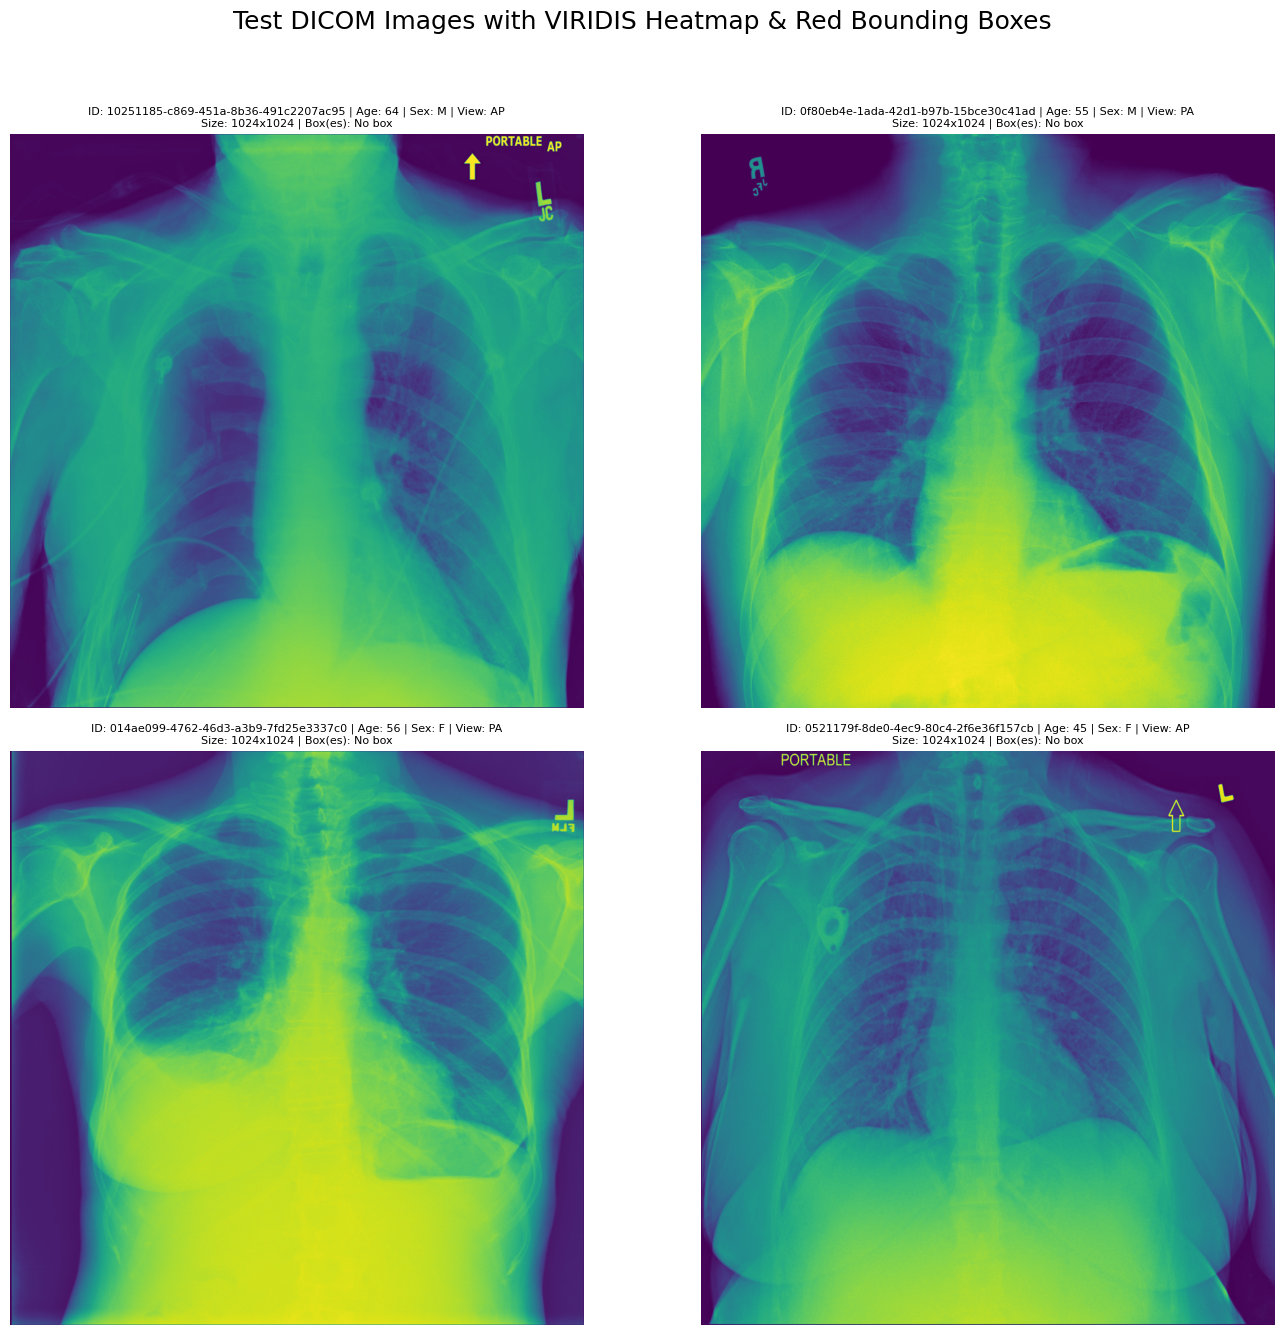

In [19]:
process_and_display_with_boxes(test_samples, "Test DICOM Images with VIRIDIS Heatmap & Red Bounding Boxes")

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def plot_predictions(
    model_path,
    image_dir,
    masks_dict,
    num_samples=6,
    img_size=64
):
    """
    Plot original image, ground truth mask, and predicted mask for a few samples.

    Args:
        model_path (str): Path to trained Keras model (.h5)
        image_dir (str): Directory containing .npy image files
        masks_dict (dict): Dictionary {patient_id: 2D mask array}
        num_samples (int): Number of samples to visualize
        img_size (int): Image/mask resolution (default: 64)
    """
    # Load model
    model = load_model(model_path)

    # Get .npy image files
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.npy')])
    image_files = image_files[:num_samples]  # limit to N samples

    # Create plot
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 3))

    for i, fname in enumerate(image_files):
        patient_id = os.path.splitext(fname)[0]
        image_path = os.path.join(image_dir, fname)

        # Load and preprocess image
        image = np.load(image_path) / 255.0
        if image.ndim == 2:
            image = image[..., np.newaxis]  # ensure shape (64, 64, 1)
        input_image = np.expand_dims(image, axis=0)  # shape: (1, 64, 64, 1)

        # Predict mask
        pred_mask = model.predict(input_image, verbose=0)[0, :, :, 0]
        pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)

        # Load ground truth mask from dictionary
        gt_mask = masks_dict.get(patient_id, np.zeros((img_size, img_size)))

        # Plot image
        axes[i, 0].imshow(image.squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Original Image\n{patient_id}")
        axes[i, 0].axis('off')

        # Plot ground truth mask
        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis('off')

        # Plot predicted mask
        axes[i, 2].imshow(pred_mask_bin, cmap='gray')
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


In [28]:
# Assumes you have: image_paths (list of .dcm files), pneumonia_labels (Target == 1 rows from CSV)

masks = {}
for path in image_paths:
    img_id = os.path.basename(path).replace('.dcm', '')
    dcm = pydicom.dcmread(path)
    orig_shape = dcm.pixel_array.shape  # Usually (1024, 1024) or similar
    mask = create_segmentation_mask(img_id, labels_df, orig_size=orig_shape, new_size=(64, 64))
    masks[img_id] = mask


In [30]:
mask_pixels = [np.sum(m) for m in y_train]
print(np.mean(mask_pixels), np.max(mask_pixels))  # If all zeros, bad!



170.251875 2194


In [32]:
# Filter for pneumonia-only samples
labels_df = pd.read_csv(r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_labels.csv")

pneumonia_ids = set(labels_df[labels_df["Target"] == 1]["patientId"])

# Keep only DICOMs with pneumonia
image_paths = [p for p in image_paths if os.path.basename(p).replace(".dcm", "") in pneumonia_ids]


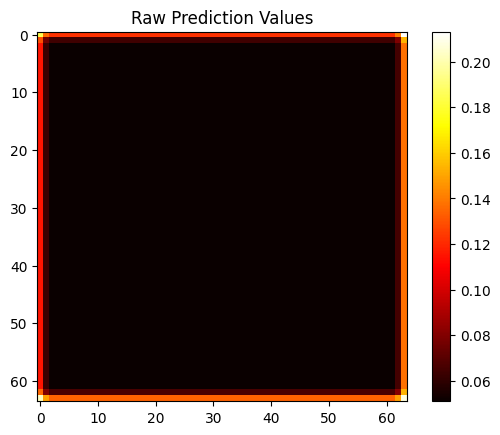

In [33]:
plt.imshow(pred_mask, cmap='hot')
plt.title("Raw Prediction Values")
plt.colorbar()
plt.show()


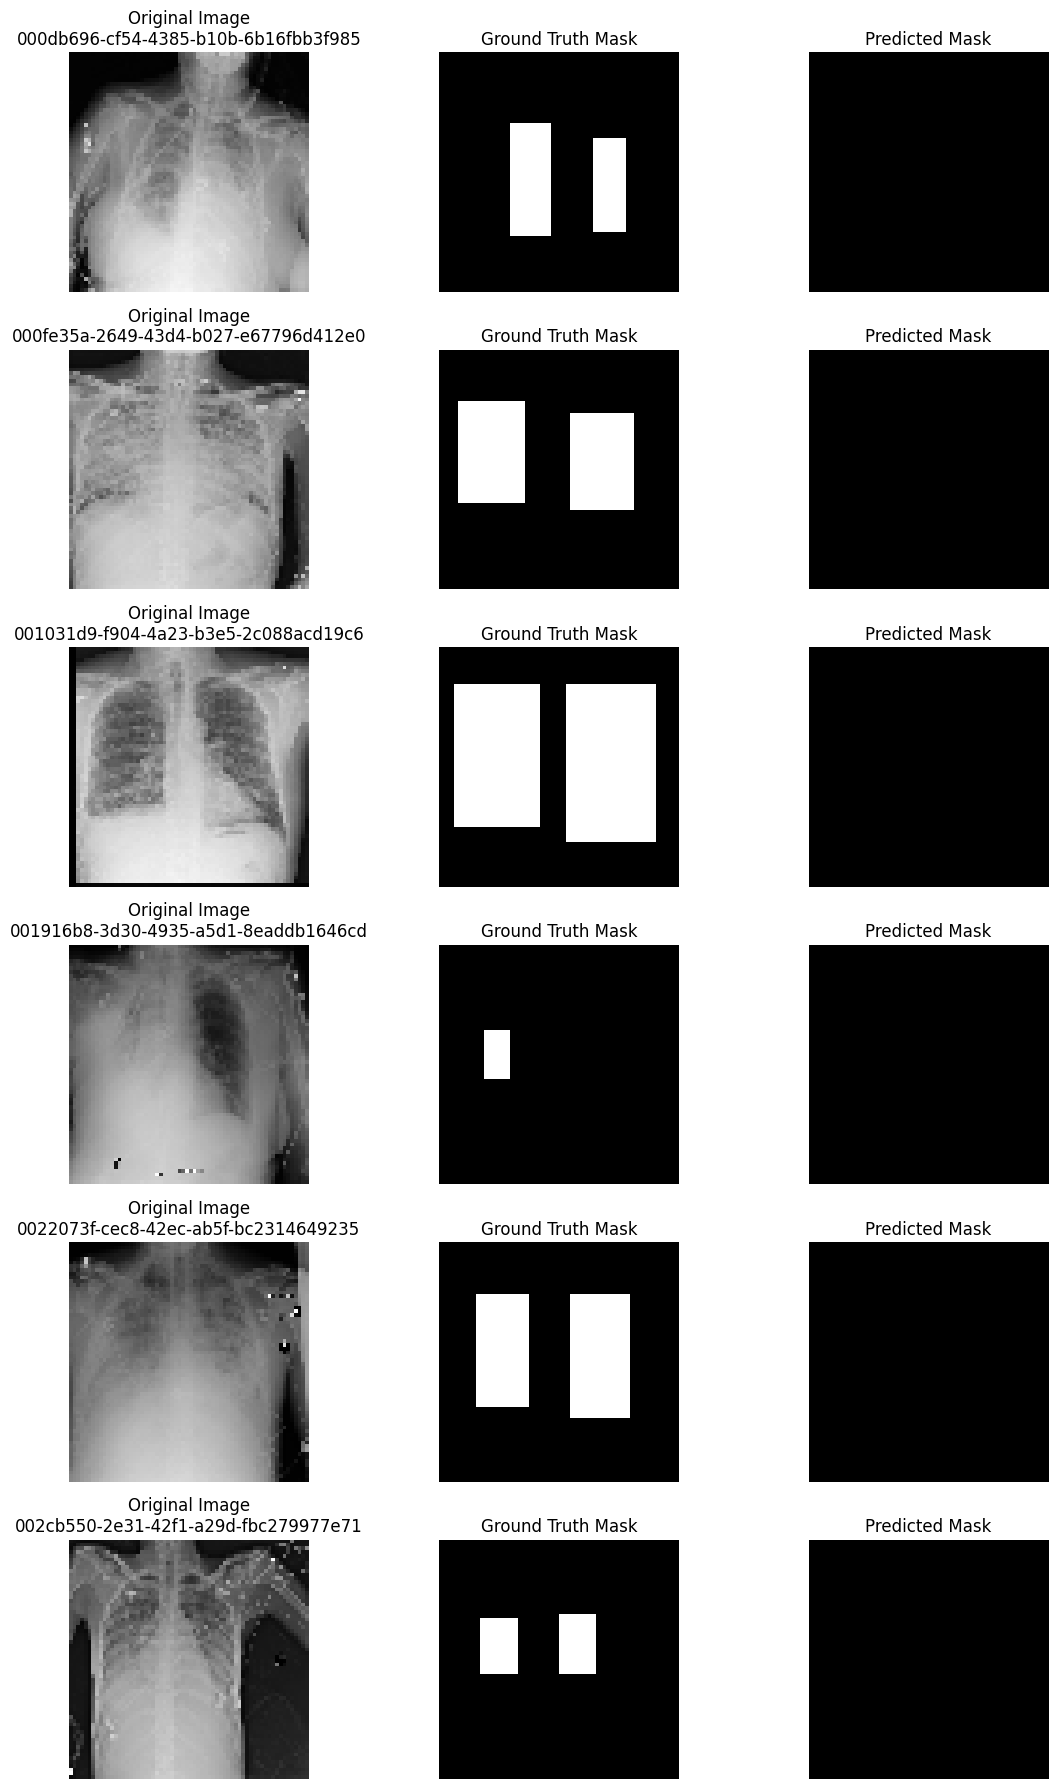

In [29]:
plot_predictions(
    model_path=r"C:\Users\samya\PyCharmProject\Pneumonia-Detection\xray_model.h5",
    image_dir="npy_images",
    masks_dict=masks,
    num_samples=6  # or 10, 20, etc.
)


Using DICOM file: C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images\8d8d2dd7-b0b0-444f-b4a9-885382c8c668.dcm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step


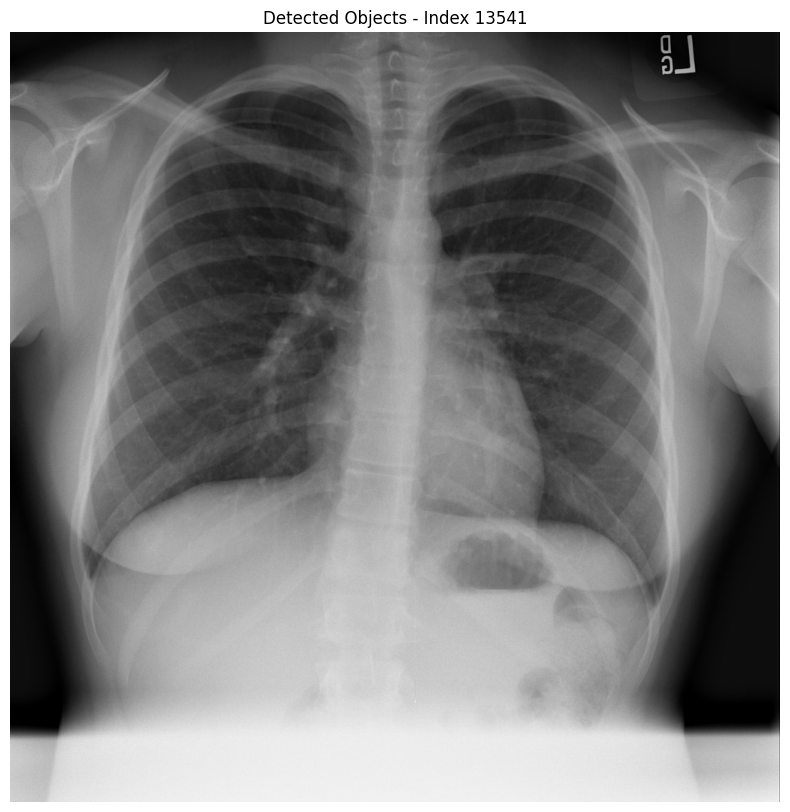

In [34]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pydicom
from tensorflow.keras.models import load_model

# --- Define DICOM path loader ---
def get_dicom_paths(directory):
    return [os.path.join(directory, fname) for fname in os.listdir(directory) if fname.endswith(".dcm")]

# --- Directories ---
TRAIN_IMG_DIR = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
train_img_path = get_dicom_paths(TRAIN_IMG_DIR)

# --- Load U-Net model ---
model = load_model(r'C:\Users\samya\PyCharmProject\Pneumonia-Detection\xray_model.h5')  # Replace with your actual model path

# --- Select a random image beyond the first 5000 ---
random_index = random.choice(range(5000, len(train_img_path)))
dicom_path = train_img_path[random_index]
print(f"Using DICOM file: {dicom_path}")

# --- Load and preprocess DICOM image ---
dicom = pydicom.dcmread(dicom_path)
image = dicom.pixel_array.astype(np.float32)
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
original_size = image.shape

# Resize to model input size and convert to 3 channels
input_image = cv2.resize(image, (64, 64))
input_image = cv2.cvtColor(input_image, cv2.COLOR_GRAY2RGB)
input_image = input_image / 255.0
input_image = np.expand_dims(input_image, axis=0)  # Shape: (1, 64, 64, 3)

# --- Predict segmentation mask ---
predicted_mask = model.predict(input_image)[0, :, :, 0]
binary_mask = (predicted_mask > 0.5).astype(np.uint8) * 255
binary_mask_resized = cv2.resize(binary_mask, (original_size[1], original_size[0]))

# --- Find contours and draw bounding boxes ---
contours, _ = cv2.findContours(binary_mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

# --- Display result ---
plt.figure(figsize=(10, 10))
plt.imshow(output_image)
plt.title(f"Detected Objects - Index {random_index}")
plt.axis('off')
plt.show()